In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats
from sparrow import Protein

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
construct_stats = pd.read_csv('constructs_df.csv', index_col=0)

construct_stats['construct'] = construct_stats['construct'].astype(str)

In [3]:
# Function to calculate sequence features and predictions using sparrow
def calculate_sparrow_features(seqs_df):
    features = []
    for idx, row in seqs_df.iterrows():
        seq = row['sequence']
        construct = row['construct']
        protein = Protein(seq)
        
        # Calculate features
        f_positive = protein.fraction_positive
        f_negative = protein.fraction_negative
        aro = protein.fraction_aromatic
        ali = protein.fraction_aliphatic
        polar = protein.fraction_polar
        proline = protein.fraction_proline
        scd = protein.SCD                    # Uppercase SCD
        shd = protein.SHD                    # Uppercase SHD
        ncpr = protein.NCPR                  # Uppercase NCPR
        fcr = protein.FCR                    # Uppercase FCR
        hydrophobicity = protein.hydrophobicity
        kappa = protein.kappa
        
        # Predictions
        rg = protein.predictor.radius_of_gyration()
        re = protein.predictor.end_to_end_distance()
        mean_disorder = np.mean(protein.predictor.disorder())
        asphericity = protein.predictor.asphericity()
        scaling_exp = protein.predictor.scaling_exponent()
        prefactor = protein.predictor.prefactor()
        coil = protein.predictor.dssp_coil()
        extended = protein.predictor.dssp_extended()
        helicity = protein.predictor.dssp_helicity()
        
        features.append({
            'construct': construct,
            'f_positive': f_positive,
            'f_negative': f_negative,
            'aro': aro,
            'ali': ali,
            'polar': polar,
            'proline': proline,
            'scd': scd,
            'shd': shd,
            'NCPR': ncpr,
            'FCR': fcr,
            'hydrophobicity': hydrophobicity,
            'kappa': kappa,
            'rg': rg,
            're': re,
            'mean_disorder': mean_disorder,
            'asphericity': asphericity,
            'scaling_exponent': scaling_exp,
            'prefactor': prefactor,
            'coil': coil,
            'extended': extended,
            'helicity': helicity
        })
    return pd.DataFrame(features)

# Calculate features and predictions, then merge with construct_stats
sparrow_features = calculate_sparrow_features(construct_stats)
construct_stats = construct_stats.merge(sparrow_features, on='construct', how='left')

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


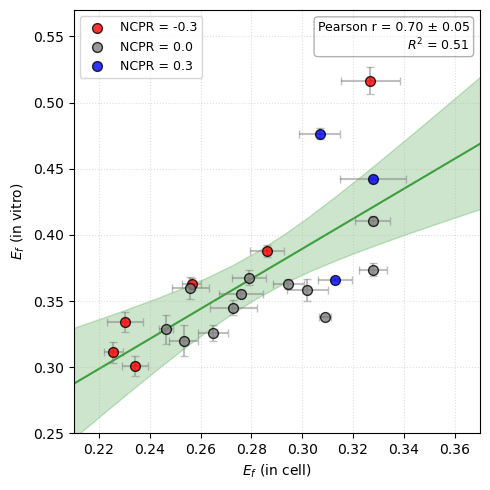

In [4]:
# plot Ef_cell vs Ef_invitro with error bars - with color parameter
mask = construct_stats[['Ef_cell', 'Ef_cell_std', 'Ef_invitro', 'Ef_invitro_std']].notnull().all(axis=1)
plot_df = construct_stats.loc[mask].copy()

x = plot_df['Ef_cell']
y = plot_df['Ef_invitro']
xerr = plot_df['Ef_cell_std']
yerr = plot_df['Ef_invitro_std']

# Round NCPR to nearest tenth and categorize
plot_df['NCPR_rounded'] = np.round(plot_df['NCPR'], 1)

# Create color mapping based on NCPR categories
color_map = {-0.3: 'red', 0.0: 'gray', 0.3: 'blue'}
plot_df['color'] = plot_df['NCPR_rounded'].map(color_map)

# Monte Carlo sampling for Pearson correlation
n_iterations = 1000
pearson_values = []

for _ in range(n_iterations):
    sampled_x = np.random.normal(plot_df['Ef_cell'], plot_df['Ef_cell_std'])
    sampled_y = np.random.normal(plot_df['Ef_invitro'], plot_df['Ef_invitro_std'])
    pearson_r_sample, _ = sp_stats.pearsonr(sampled_x, sampled_y)
    pearson_values.append(pearson_r_sample)

pearson_r_mean = np.mean(pearson_values)
pearson_r_std = np.std(pearson_values)

fig, ax = plt.subplots(figsize=(5, 5))

# Linear regression
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(x, y)

# Calculate 95% confidence interval for the regression line
n = len(x)
dof = n - 2  # degrees of freedom
t_val = sp_stats.t.ppf(0.975, dof)  # 95% confidence interval

x_mean = np.mean(x)
sxx = np.sum((x - x_mean)**2)

# Get x limits and create line
x_limits = ax.get_xlim()
line_x = np.linspace(x_limits[0], x_limits[1], 100)
line_y = slope * line_x + intercept

# Calculate prediction error
predict_y = slope * x + intercept
residuals = y - predict_y
s_resid = np.sqrt(np.sum(residuals**2) / dof)

# Standard error of the fit
se_line = s_resid * np.sqrt(1/n + (line_x - x_mean)**2 / sxx)
margin = t_val * se_line

# Plot shaded confidence interval
ax.fill_between(line_x, line_y - margin, line_y + margin,
                color='green', alpha=0.2, zorder=0)

# Plot regression line
ax.plot(line_x, line_y, color='green', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)

# Plot points by category
for ncpr_val, color in color_map.items():
    mask_cat = plot_df['NCPR_rounded'] == ncpr_val
    if mask_cat.any():
        ax.scatter(plot_df.loc[mask_cat, 'Ef_cell'], 
                  plot_df.loc[mask_cat, 'Ef_invitro'],
                  c=color, edgecolors='black', linewidths=1, 
                  alpha=0.8, s=50, zorder=2, label=f'NCPR = {ncpr_val}')

# Add error bars
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
            ecolor='grey', capsize=3, alpha=0.5, zorder=1)

# Add legend in top left
ax.legend(loc='upper left', frameon=True, fontsize=9)

ax.set_xlabel('$E_{f}$ (in cell)')
ax.set_ylabel('$E_{f}$ (in vitro)')
ax.grid(True, linestyle=':', alpha=0.4)

ax.text(0.975, 0.975, f'Pearson r = {pearson_r_mean:.2f} ± {pearson_r_std:.2f}\n$R^2$ = {r_value**2:.2f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.3))

plt.xlim(0.21, .37)
plt.ylim(.25, .57)
plt.tight_layout()
#plt.savefig('Figure_graphs/Fig2/Ef_incell-vs-invitro.svg')

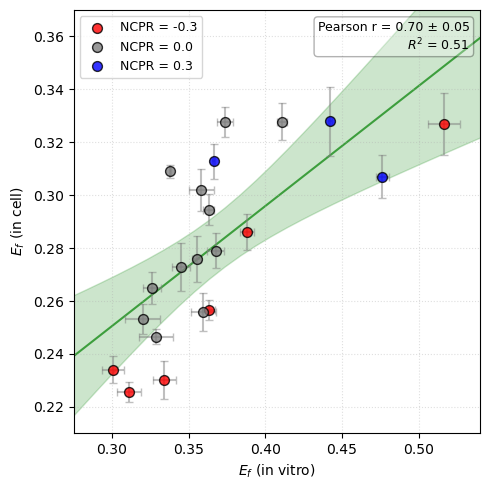

In [5]:
# plot Ef_cell vs Ef_invitro with error bars - with color parameter
mask = construct_stats[['Ef_cell', 'Ef_cell_std', 'Ef_invitro', 'Ef_invitro_std']].notnull().all(axis=1)
plot_df = construct_stats.loc[mask].copy()

# Switch axes: invitro on x, cell on y
x = plot_df['Ef_invitro']
y = plot_df['Ef_cell']
xerr = plot_df['Ef_invitro_std']
yerr = plot_df['Ef_cell_std']

# Round NCPR to nearest tenth and categorize
plot_df['NCPR_rounded'] = np.round(plot_df['NCPR'], 1)

# Create color mapping based on NCPR categories
color_map = {-0.3: 'red', 0.0: 'gray', +0.3: 'blue'}
plot_df['color'] = plot_df['NCPR_rounded'].map(color_map)

# Monte Carlo sampling for Pearson correlation
n_iterations = 1000
pearson_values = []

for _ in range(n_iterations):
    sampled_x = np.random.normal(plot_df['Ef_invitro'], plot_df['Ef_invitro_std'])
    sampled_y = np.random.normal(plot_df['Ef_cell'], plot_df['Ef_cell_std'])
    pearson_r_sample, _ = sp_stats.pearsonr(sampled_x, sampled_y)
    pearson_values.append(pearson_r_sample)

pearson_r_mean = np.mean(pearson_values)
pearson_r_std = np.std(pearson_values)

fig, ax = plt.subplots(figsize=(5, 5))

# Linear regression
slope, intercept, r_value, p_value, std_err = sp_stats.linregress(x, y)

# Calculate 95% confidence interval for the regression line
n = len(x)
dof = n - 2  # degrees of freedom
t_val = sp_stats.t.ppf(0.975, dof)  # 95% confidence interval

x_mean = np.mean(x)
sxx = np.sum((x - x_mean)**2)

# Get x limits and create line
x_limits = ax.get_xlim()
line_x = np.linspace(x_limits[0], x_limits[1], 100)
line_y = slope * line_x + intercept

# Calculate prediction error
predict_y = slope * x + intercept
residuals = y - predict_y
s_resid = np.sqrt(np.sum(residuals**2) / dof)

# Standard error of the fit
se_line = s_resid * np.sqrt(1/n + (line_x - x_mean)**2 / sxx)
margin = t_val * se_line

# Plot shaded confidence interval
ax.fill_between(line_x, line_y - margin, line_y + margin,
                color='green', alpha=0.2, zorder=0)

# Plot regression line
ax.plot(line_x, line_y, color='green', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)

# Plot points by category
for ncpr_val, color in color_map.items():
    mask_cat = plot_df['NCPR_rounded'] == ncpr_val
    if mask_cat.any():
        ax.scatter(plot_df.loc[mask_cat, 'Ef_invitro'], 
                  plot_df.loc[mask_cat, 'Ef_cell'],
                  c=color, edgecolors='black', linewidths=1, 
                  alpha=0.8, s=50, zorder=2, label=f'NCPR = {ncpr_val}')

# Add error bars
ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
            ecolor='grey', capsize=3, alpha=0.5, zorder=1)

# Add legend in top left
ax.legend(loc='upper left', frameon=True, fontsize=9)

ax.set_xlabel('$E_{f}$ (in vitro)')
ax.set_ylabel('$E_{f}$ (in cell)')
ax.grid(True, linestyle=':', alpha=0.4)

ax.text(0.975, 0.975, f'Pearson r = {pearson_r_mean:.2f} ± {pearson_r_std:.2f}\n$R^2$ = {r_value**2:.2f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.3))

plt.xlim(.275, .54)
plt.ylim(0.21, .37)
plt.tight_layout()
plt.savefig('Figure_graphs/Fig2/Ef_incell-vs-invitro.svg')

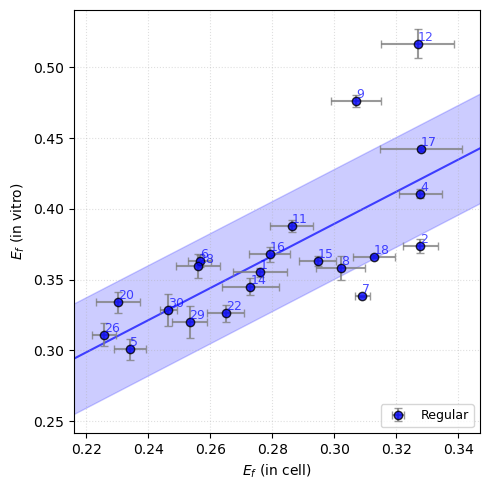

In [6]:
# plot Ef_cell vs Ef_invitro with error bars - BLUE for regular, GREY for GS
mask = construct_stats[['Ef_cell', 'Ef_cell_std', 'Ef_invitro', 'Ef_invitro_std']].notnull().all(axis=1)
plot_df = construct_stats.loc[mask].copy()

regular_df = plot_df[~plot_df['construct'].str.contains('GS', na=False)]

fig, ax = plt.subplots(figsize=(5, 5))

# Plot regular points in blue
if len(regular_df) > 0:
    ax.errorbar(regular_df['Ef_cell'], regular_df['Ef_invitro'], 
                xerr=regular_df['Ef_cell_std'], yerr=regular_df['Ef_invitro_std'],
                fmt='o', color='blue', markeredgecolor='black', markeredgewidth=1,
                ecolor='grey', capsize=3, alpha=0.8, barsabove=False, label='Regular')
    
    # Add labels to regular points
    for idx, row in regular_df.iterrows():
        ax.text(row['Ef_cell'], row['Ef_invitro'], 
                row['construct'], fontsize=9, alpha=0.7, 
                ha='left', va='bottom', color='blue')

# Linear regression for REGULAR constructs
if len(regular_df) > 1:
    x_regular = regular_df['Ef_cell']
    y_regular = regular_df['Ef_invitro']
    
    slope_reg, intercept_reg, r_value_reg, p_value_reg, std_err_reg = sp_stats.linregress(x_regular, y_regular)
    pearson_r_reg, pearson_p_reg = sp_stats.pearsonr(x_regular, y_regular)
    
    x_limits = ax.get_xlim()
    line_x_reg = np.array(x_limits)
    line_y_reg = slope_reg * line_x_reg + intercept_reg
    
    ax.plot(line_x_reg, line_y_reg, color='blue', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)
    
    # Calculate 95% confidence interval for regular
    n_reg = len(x_regular)
    dof_reg = n_reg - 2
    t_val_reg = sp_stats.t.ppf(0.975, dof_reg)
    x_mean_reg = np.mean(x_regular)
    sxx_reg = np.sum((x_regular - x_mean_reg)**2)
    predict_y_reg = slope_reg * x_regular + intercept_reg
    residuals_reg = y_regular - predict_y_reg
    s_resid_reg = np.sqrt(np.sum(residuals_reg**2) / dof_reg)
    se_line_reg = s_resid_reg * np.sqrt(1/n_reg + (line_x_reg - x_mean_reg)**2 / sxx_reg)
    margin_reg = t_val_reg * se_line_reg
    
    ax.fill_between(line_x_reg, line_y_reg - margin_reg, line_y_reg + margin_reg,
                    color='blue', alpha=0.2, zorder=0)

ax.set_xlabel('$E_{f}$ (in cell)')
ax.set_ylabel('$E_{f}$ (in vitro)')
ax.grid(True, linestyle=':', alpha=0.4)

# Add statistics text for regular constructs

ax.legend(loc='lower right', frameon=True, fontsize=9)

plt.xlim(x_limits[0], x_limits[1])
plt.tight_layout()
#plt.savefig('Figure_graphs/Fig2/Ef_cell_vs_Ef_invitro_all_blue.svg')